In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, linalg
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# Random seed
# ============================================================
GLOBAL_SEED = 123
rng_global = np.random.default_rng(GLOBAL_SEED)


# ============================================================
# Utility: stable matrix square root for PSD matrices
# ============================================================
def symmetrize(A):
    return 0.5 * (A + A.T)


def psd_matrix_sqrt(A, eps=1e-12):
    A = symmetrize(A)
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, eps, None)
    return vecs @ np.diag(np.sqrt(vals)) @ vecs.T


# ============================================================
# Gaussian W2 distance
# W2^2(N(m1,S1), N(m2,S2))
#   = ||m1-m2||^2 + tr(S1 + S2 - 2 (S2^(1/2) S1 S2^(1/2))^(1/2))
# ============================================================
def gaussian_w2_from_stats(m1, S1, m2, S2, eps=1e-10):
    S1 = symmetrize(S1) + eps * np.eye(S1.shape[0])
    S2 = symmetrize(S2) + eps * np.eye(S2.shape[0])

    diff_term = np.sum((m1 - m2) ** 2)

    S2_sqrt = psd_matrix_sqrt(S2, eps=eps)
    middle = S2_sqrt @ S1 @ S2_sqrt
    middle_sqrt = psd_matrix_sqrt(middle, eps=eps)

    cov_term = np.trace(S1 + S2 - 2.0 * middle_sqrt)
    cov_term = max(cov_term, 0.0)

    return np.sqrt(diff_term + cov_term)


def empirical_mean_cov(samples):
    mean = np.mean(samples, axis=0)
    cov = np.cov(samples.T, bias=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    return mean, cov


def gaussian_w2_from_samples(samples1, samples2, eps=1e-10):
    m1, S1 = empirical_mean_cov(samples1)
    m2, S2 = empirical_mean_cov(samples2)
    return gaussian_w2_from_stats(m1, S1, m2, S2, eps=eps)


# ============================================================
# Optional: empirical matching-based W2 approximation
# Warning: O(n^3), use only when number of samples is small.
# ============================================================
def empirical_w2_matching(samples1, samples2):
    n1, d1 = samples1.shape
    n2, d2 = samples2.shape
    if n1 != n2:
        raise ValueError("samples1 and samples2 must have the same number of samples.")
    if d1 != d2:
        raise ValueError("Dimension mismatch.")

    cost = np.sum((samples1[:, None, :] - samples2[None, :, :]) ** 2, axis=2)
    row_ind, col_ind = linear_sum_assignment(cost)
    return np.sqrt(cost[row_ind, col_ind].mean())


# ============================================================
# Synthetic data generators
# ============================================================
def generate_poisson_data(
    sample_size=2000,
    dimension=2,
    theta_loc=0.0,
    theta_scale=1.0,
    bias=1.0,
    variance_list=(1, 2, 3, 4, 5),
    seed=123
):
    rng = np.random.default_rng(seed)

    cov_x = np.zeros(dimension)
    for i in range(dimension):
        cov_x[i] = 1.0 / (rng.choice(variance_list) * sample_size)

    X = rng.multivariate_normal(
        mean=np.zeros(dimension),
        cov=np.diag(cov_x),
        size=sample_size
    )
    theta_star = rng.normal(loc=theta_loc, scale=theta_scale, size=dimension)
    eta = X @ theta_star + bias
    mu = np.exp(eta)
    y = rng.poisson(mu)

    return X, y.astype(float), theta_star


def generate_negative_binomial_data(
    sample_size=2000,
    dimension=2,
    theta_loc=0.5,
    theta_scale=1.0,
    bias=1.0,
    r_dispersion=5.0,
    variance_list=(1, 2, 3, 4, 5),
    seed=123
):
    """
    Negative binomial with mean mu = exp(x^T theta + bias),
    variance mu + mu^2 / r.
    """
    rng = np.random.default_rng(seed)

    cov_x = np.zeros(dimension)
    for i in range(dimension):
        cov_x[i] = 1.0 / (rng.choice(variance_list) * sample_size)

    X = rng.multivariate_normal(
        mean=np.zeros(dimension),
        cov=np.diag(cov_x),
        size=sample_size
    )
    theta_star = rng.normal(loc=theta_loc, scale=theta_scale, size=dimension)
    eta = X @ theta_star + bias
    mu = np.exp(eta)

    # Gamma-Poisson mixture
    shape = r_dispersion
    scale = mu / r_dispersion
    lam = rng.gamma(shape=shape, scale=scale)
    y = rng.poisson(lam)

    return X, y.astype(float), theta_star


# ============================================================
# Real data loader
# ============================================================
def load_real_dataset_with_pca(
    csv_path,
    target_col="loss",
    sample_size=5000,
    dimension=10
):
    df = pd.read_csv(csv_path)
    df = df.iloc[:sample_size].copy()

    X = df.drop(columns=[target_col]).to_numpy()
    y = df[target_col].to_numpy()

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    pca = PCA(n_components=dimension)
    X = pca.fit_transform(X)

    return X, y


# ============================================================
# Model definitions
# Supported:
#   - "linear": squared loss / 2
#   - "poisson": Poisson negative log-likelihood
# ============================================================
class LinearRegressionModel:
    name = "linear"

    @staticmethod
    def loss_full(theta, X, y):
        r = X @ theta - y
        return 0.5 * np.mean(r ** 2)

    @staticmethod
    def grad_full(theta, X, y):
        r = X @ theta - y
        return X.T @ r / X.shape[0]

    @staticmethod
    def hess_full(theta, X, y):
        return X.T @ X / X.shape[0]

    @staticmethod
    def grad_i(theta, x_i, y_i):
        return (x_i @ theta - y_i) * x_i

    @staticmethod
    def hess_i(theta, x_i, y_i):
        return np.outer(x_i, x_i)

    @staticmethod
    def fit_theta_hat(X, y, theta0=None):
        N, d = X.shape
        if theta0 is None:
            theta0 = np.zeros(d)

        res = optimize.minimize(
            fun=lambda th: LinearRegressionModel.loss_full(th, X, y),
            x0=theta0,
            jac=lambda th: LinearRegressionModel.grad_full(th, X, y),
            method="BFGS"
        )
        return res.x


class PoissonRegressionModel:
    name = "poisson"

    @staticmethod
    def _clip_eta(eta, clip=30.0):
        return np.clip(eta, -clip, clip)

    @staticmethod
    def loss_full(theta, X, y):
        eta = PoissonRegressionModel._clip_eta(X @ theta)
        mu = np.exp(eta)
        # ignore constant log(y!)
        return np.mean(mu - y * eta)

    @staticmethod
    def grad_full(theta, X, y):
        eta = PoissonRegressionModel._clip_eta(X @ theta)
        mu = np.exp(eta)
        return X.T @ (mu - y) / X.shape[0]

    @staticmethod
    def hess_full(theta, X, y):
        eta = PoissonRegressionModel._clip_eta(X @ theta)
        mu = np.exp(eta)
        return (X.T * mu) @ X / X.shape[0]

    @staticmethod
    def grad_i(theta, x_i, y_i):
        eta = np.clip(x_i @ theta, -30.0, 30.0)
        mu = np.exp(eta)
        return (mu - y_i) * x_i

    @staticmethod
    def hess_i(theta, x_i, y_i):
        eta = np.clip(x_i @ theta, -30.0, 30.0)
        mu = np.exp(eta)
        return mu * np.outer(x_i, x_i)

    @staticmethod
    def fit_theta_hat(X, y, theta0=None):
        N, d = X.shape
        if theta0 is None:
            theta0 = np.zeros(d)

        res = optimize.minimize(
            fun=lambda th: PoissonRegressionModel.loss_full(th, X, y),
            x0=theta0,
            jac=lambda th: PoissonRegressionModel.grad_full(th, X, y),
            method="BFGS",
            options={"maxiter": 2000}
        )
        return res.x


# ============================================================
# Build quadratic surrogate at theta_hat
#
# \tilde ell_i(theta)
#   = ell_i(theta_hat)
#   + g_i(theta_hat)^T (theta-theta_hat)
#   + 1/2 (theta-theta_hat)^T H_i(theta_hat) (theta-theta_hat)
#
# We only need gradient:
#   grad \tilde ell_i(theta) = g_i_hat + H_i_hat (theta-theta_hat)
# ============================================================
def precompute_surrogate_terms(model, X, y, theta_hat):
    N, d = X.shape
    g_list = np.zeros((N, d))
    H_list = np.zeros((N, d, d))
    for i in range(N):
        g_list[i] = model.grad_i(theta_hat, X[i], y[i])
        H_list[i] = model.hess_i(theta_hat, X[i], y[i])
    return g_list, H_list


# ============================================================
# SGD paths
# ============================================================
def sgd_path_original(
    model,
    X,
    y,
    theta0,
    batch_size,
    lr,
    n_iters,
    seed=123
):
    rng = np.random.default_rng(seed)
    N, d = X.shape
    theta = theta0.copy()
    path = np.zeros((n_iters + 1, d))
    path[0] = theta.copy()

    for t in range(n_iters):
        idx = rng.choice(N, size=batch_size, replace=False)
        grad_batch = np.mean(
            [model.grad_i(theta, X[i], y[i]) for i in idx],
            axis=0
        )
        theta = theta - lr * grad_batch
        path[t + 1] = theta.copy()

    return path


def sgd_path_surrogate(
    X,
    theta0,
    theta_hat,
    g_list,
    H_list,
    batch_size,
    lr,
    n_iters,
    seed=123
):
    rng = np.random.default_rng(seed)
    N, d = X.shape
    theta = theta0.copy()
    path = np.zeros((n_iters + 1, d))
    path[0] = theta.copy()

    for t in range(n_iters):
        idx = rng.choice(N, size=batch_size, replace=False)
        delta = theta - theta_hat
        grad_batch = np.mean(
            [g_list[i] + H_list[i] @ delta for i in idx],
            axis=0
        )
        theta = theta - lr * grad_batch
        path[t + 1] = theta.copy()

    return path


# ============================================================
# Extract approximate stationary samples
# ============================================================
def get_stationary_samples(path, burnin_frac=0.5, thin=10, max_keep=None):
    n = path.shape[0]
    start = int(np.floor(burnin_frac * n))
    samples = path[start::thin]
    if max_keep is not None and samples.shape[0] > max_keep:
        idx = np.linspace(0, samples.shape[0] - 1, max_keep).astype(int)
        samples = samples[idx]
    return samples


# ============================================================
# Run one configuration
# ============================================================
def run_one_configuration(
    model,
    X,
    y,
    theta_hat,
    g_list,
    H_list,
    batch_size,
    lr,
    n_iters,
    burnin_frac=0.5,
    thin=10,
    max_keep=500,
    seed=123,
    w2_mode="gaussian"
):
    path_true = sgd_path_original(
        model=model,
        X=X,
        y=y,
        theta0=theta_hat,
        batch_size=batch_size,
        lr=lr,
        n_iters=n_iters,
        seed=seed
    )

    path_surr = sgd_path_surrogate(
        X=X,
        theta0=theta_hat,
        theta_hat=theta_hat,
        g_list=g_list,
        H_list=H_list,
        batch_size=batch_size,
        lr=lr,
        n_iters=n_iters,
        seed=seed + 100000
    )

    samples_true = get_stationary_samples(
        path_true, burnin_frac=burnin_frac, thin=thin, max_keep=max_keep
    )
    samples_surr = get_stationary_samples(
        path_surr, burnin_frac=burnin_frac, thin=thin, max_keep=max_keep
    )

    if w2_mode == "gaussian":
        w2 = gaussian_w2_from_samples(samples_true, samples_surr)
    elif w2_mode == "matching":
        m = min(len(samples_true), len(samples_surr))
        samples_true = samples_true[:m]
        samples_surr = samples_surr[:m]
        w2 = empirical_w2_matching(samples_true, samples_surr)
    else:
        raise ValueError("w2_mode must be 'gaussian' or 'matching'.")

    return {
        "w2": w2,
        "samples_true": samples_true,
        "samples_surr": samples_surr,
        "path_true": path_true,
        "path_surr": path_surr,
    }


# ============================================================
# Experiment runner
# ============================================================
def run_scaling_experiment(
    model,
    X,
    y,
    dataset_name,
    batch_sizes=(16, 32, 256),
    ratio_grid=None,
    n_epochs=200,
    burnin_frac=0.5,
    thin=10,
    max_keep=500,
    n_reps=5,
    fit_seed=123,
    w2_mode="gaussian"
):
    """
    ratio_grid = values of lambda / B
    lr = ratio * B
    """
    N, d = X.shape
    if ratio_grid is None:
        ratio_grid = [0.25 / N, 0.5 / N, 1.0 / N, 1.5 / N]

    theta0 = np.zeros(d)
    theta_hat = model.fit_theta_hat(X, y, theta0=theta0)
    g_list, H_list = precompute_surrogate_terms(model, X, y, theta_hat)

    all_rows = []

    for B in batch_sizes:
        n_iters = int(np.ceil(n_epochs * N / B))
        for ratio in ratio_grid:
            lr = ratio * B

            w2_list = []
            for rep in range(n_reps):
                out = run_one_configuration(
                    model=model,
                    X=X,
                    y=y,
                    theta_hat=theta_hat,
                    g_list=g_list,
                    H_list=H_list,
                    batch_size=B,
                    lr=lr,
                    n_iters=n_iters,
                    burnin_frac=burnin_frac,
                    thin=thin,
                    max_keep=max_keep,
                    seed=fit_seed + 1000 * rep + 17 * B,
                    w2_mode=w2_mode
                )
                w2_list.append(out["w2"])

            row = {
                "dataset": dataset_name,
                "model": model.name,
                "N": N,
                "d": d,
                "B": B,
                "lambda_over_B": ratio,
                "lr": lr,
                "n_iters": n_iters,
                "w2_mean": float(np.mean(w2_list)),
                "w2_std": float(np.std(w2_list, ddof=1)) if len(w2_list) > 1 else 0.0,
                "w2_q025": float(np.quantile(w2_list, 0.025)),
                "w2_q975": float(np.quantile(w2_list, 0.975)),
            }
            all_rows.append(row)
            print(
                f"[{dataset_name}] B={B:>3d}, lambda/B={ratio:.6e}, "
                f"lr={lr:.6e}, W2={row['w2_mean']:.6e} ± {row['w2_std']:.6e}"
            )

    results = pd.DataFrame(all_rows)
    return results, theta_hat


# ============================================================
# Plot helpers
# ============================================================
def plot_w2_vs_lambda_over_B(results_df, title=None):
    plt.figure(figsize=(7, 5))
    for B in sorted(results_df["B"].unique()):
        sub = results_df[results_df["B"] == B].sort_values("lambda_over_B")
        x = sub["lambda_over_B"].to_numpy()
        y = sub["w2_mean"].to_numpy()
        yerr_lower = y - sub["w2_q025"].to_numpy()
        yerr_upper = sub["w2_q975"].to_numpy() - y

        plt.errorbar(
            x, y,
            yerr=[yerr_lower, yerr_upper],
            marker="o",
            capsize=3,
            label=f"B={B}"
        )

    plt.xlabel(r"$\lambda/B$")
    plt.ylabel(r"Estimated $W_2(\pi_\theta,\pi_\psi)$")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_w2_vs_lambda_over_B_loglog(results_df, title=None):
    plt.figure(figsize=(7, 5))
    for B in sorted(results_df["B"].unique()):
        sub = results_df[results_df["B"] == B].sort_values("lambda_over_B")
        plt.plot(
            sub["lambda_over_B"].to_numpy(),
            sub["w2_mean"].to_numpy(),
            marker="o",
            label=f"B={B}"
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$\lambda/B$")
    plt.ylabel(r"Estimated $W_2(\pi_\theta,\pi_\psi)$")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage: synthetic Poisson / misspecified NB
# ============================================================
if __name__ == "__main__":
    # --------------------------------------------------------
    # Common experiment settings
    # --------------------------------------------------------
    batch_sizes = [16, 32, 256]
    n_reps = 5
    n_epochs = 300
    burnin_frac = 0.5
    thin = 10
    max_keep = 500

    # ========================================================
    # 1) Synthetic Poisson data, fitted with Poisson loss
    # ========================================================
    X_syn_pois, y_syn_pois, theta_star_pois = generate_poisson_data(
        sample_size=2000,
        dimension=2,
        theta_loc=0.0,
        theta_scale=1.0,
        bias=1.0,
        seed=123
    )

    model_poisson = PoissonRegressionModel()

    ratio_grid_syn = [
        0.25 / X_syn_pois.shape[0],
        0.5 / X_syn_pois.shape[0],
        1.0 / X_syn_pois.shape[0],
        1.5 / X_syn_pois.shape[0],
        2 / X_syn_pois.shape[0]
    ]

    results_syn_pois, theta_hat_syn_pois = run_scaling_experiment(
        model=model_poisson,
        X=X_syn_pois,
        y=y_syn_pois,
        dataset_name="synthetic_poisson",
        batch_sizes=batch_sizes,
        ratio_grid=ratio_grid_syn,
        n_epochs=n_epochs,
        burnin_frac=burnin_frac,
        thin=thin,
        max_keep=max_keep,
        n_reps=n_reps,
        fit_seed=123,
        w2_mode="gaussian"
    )

    print("\nSynthetic Poisson results:")
    print(results_syn_pois)

    plot_w2_vs_lambda_over_B(
        results_syn_pois,
        title="Synthetic Poisson: W2 vs lambda/B"
    )

    # ========================================================
    # 2) Synthetic negative-binomial data, still fitted with
    #    Poisson loss (misspecified setting)
    # ========================================================
    X_syn_nb, y_syn_nb, theta_star_nb = generate_negative_binomial_data(
        sample_size=2000,
        dimension=2,
        theta_loc=0.5,
        theta_scale=1.0,
        bias=1.0,
        r_dispersion=5.0,
        seed=321
    )

    results_syn_nb, theta_hat_syn_nb = run_scaling_experiment(
        model=model_poisson,
        X=X_syn_nb,
        y=y_syn_nb,
        dataset_name="synthetic_negative_binomial_fit_poisson",
        batch_sizes=batch_sizes,
        ratio_grid=[
            0.25 / X_syn_nb.shape[0],
            0.5 / X_syn_nb.shape[0],
            1.0 / X_syn_nb.shape[0],
            1.5 / X_syn_nb.shape[0],
            2 / X_syn_nb.shape[0]
        ],
        n_epochs=n_epochs,
        burnin_frac=burnin_frac,
        thin=thin,
        max_keep=max_keep,
        n_reps=n_reps,
        fit_seed=321,
        w2_mode="gaussian"
    )

    print("\nSynthetic NB results:")
    print(results_syn_nb)

    plot_w2_vs_lambda_over_B(
        results_syn_nb,
        title="Synthetic NB (fit with Poisson loss): W2 vs lambda/B"
    )

    # ========================================================
    # 3) Real dataset with squared loss after PCA
    #    Replace csv_path with your actual path.
    # ========================================================
    csv_path = "/Users/yu/Desktop/covariance_analysis/dataset/train.csv"

    X_real, y_real = load_real_dataset_with_pca(
        csv_path=csv_path,
        target_col="loss",
        sample_size=5000,
        dimension=10
    )

    model_linear = LinearRegressionModel()

    results_real, theta_hat_real = run_scaling_experiment(
        model=model_linear,
        X=X_real,
        y=y_real,
        dataset_name="real_linear_pca",
        batch_sizes=batch_sizes,
        ratio_grid=[
            0.25 / X_syn_nb.shape[0],
            0.5 / X_syn_nb.shape[0],
            1.0 / X_syn_nb.shape[0],
            1.5 / X_syn_nb.shape[0],
            2 / X_syn_nb.shape[0]
        ],
        n_epochs=200,
        burnin_frac=burnin_frac,
        thin=thin,
        max_keep=max_keep,
        n_reps=n_reps,
        fit_seed=456,
        w2_mode="gaussian"
    )

    print("\nReal-data linear results:")
    print(results_real)

    plot_w2_vs_lambda_over_B(
        results_real,
        title="Real dataset (linear loss): W2 vs lambda/B"
    )

    # ========================================================
    # Save all results
    # ========================================================
    all_results = pd.concat(
        [results_syn_pois, results_syn_nb, results_real],
        axis=0,
        ignore_index=True
    )
    all_results.to_csv("w2_scaling_results.csv", index=False)
    print("\nSaved results to w2_scaling_results.csv")
    
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def plot_w2_scaling_icml(results_df, title=None):
    plt.figure(figsize=(6, 4))

    slopes = {}

    for B in sorted(results_df["B"].unique()):
        sub = results_df[results_df["B"] == B].sort_values("lambda_over_B")

        x = sub["lambda_over_B"].values.reshape(-1, 1)
        y = sub["w2_mean"].values

        # ----- Fit linear model through origin -----
        model = LinearRegression(fit_intercept=False)
        model.fit(x, y)
        slope = model.coef_[0]
        slopes[B] = slope

        x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
        y_line = model.predict(x_line)

        # ----- Plot -----
        plt.scatter(x, y, s=50, label=f"B={B}")
        plt.plot(x_line, y_line, linestyle="--")

    plt.xlabel(r"$\lambda/B$")
    plt.ylabel(r"$W_2(\pi_\theta, \pi_\psi)$")
    if title:
        plt.title(title)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n=== Estimated slopes (W2 ≈ slope * λ/B) ===")
    for B, s in slopes.items():
        print(f"B={B}: slope ≈ {s:.4f}")
        

from sklearn.linear_model import LinearRegression

def plot_w2_scaling_with_intercept(results_df, title=None):
    plt.figure(figsize=(6, 4))

    for B in sorted(results_df["B"].unique()):
        sub = results_df[results_df["B"] == B].sort_values("lambda_over_B")

        x = sub["lambda_over_B"].values.reshape(-1, 1)
        y = sub["w2_mean"].values

        model = LinearRegression(fit_intercept=True)
        model.fit(x, y)

        x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
        y_line = model.predict(x_line)

        plt.scatter(x, y, s=50, label=f"B={B}")
        plt.plot(x_line, y_line, linestyle="--")

        print(
            f"B={B}: intercept={model.intercept_:.6f}, slope={model.coef_[0]:.6f}"
        )

    plt.xlabel(r"$\lambda/B$")
    plt.ylabel(r"$W_2(\pi_\theta,\pi_\psi)$")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_w2_scaling_icml(
    results_syn_pois,
    title="Synthetic Poisson"
)

plot_w2_scaling_icml(
    results_syn_nb,
    title="Synthetic Poisson"
)

plot_w2_scaling_with_intercept(
    results_real,
    title="Real Data"
)



Synthetic Poisson plug-in bound info:
A: 106.90192052951599
A0: 11428.020612898952
C0: 0.023710411663823133
mu: 0.00012859694783444215
L: 0.0005138718164189031
hat_mu: 0.00012859694783444215
M_bar: 2.2791952434767053e-05
M2_bar: 2.115742461414135e-09
tau4_4: 8.302750925550563e-05
      B  lambda_over_B   w2_mean  upper_bound
0    16       0.000125  0.006587     0.013363
1    16       0.000250  0.013009     0.026725
2    16       0.000500  0.025432     0.053451
3    16       0.000750  0.037626     0.080176
4    16       0.001000  0.049159     0.106902
5    32       0.000125  0.007151     0.013363
6    32       0.000250  0.014136     0.026725
7    32       0.000500  0.027649     0.053451
8    32       0.000750  0.040782     0.080176
9    32       0.001000  0.053547     0.106902
10  256       0.000125  0.004767     0.013363
11  256       0.000250  0.009388     0.026725
12  256       0.000500  0.018236     0.053451
13  256       0.000750  0.026858     0.080176
14  256       0.001000  0.03

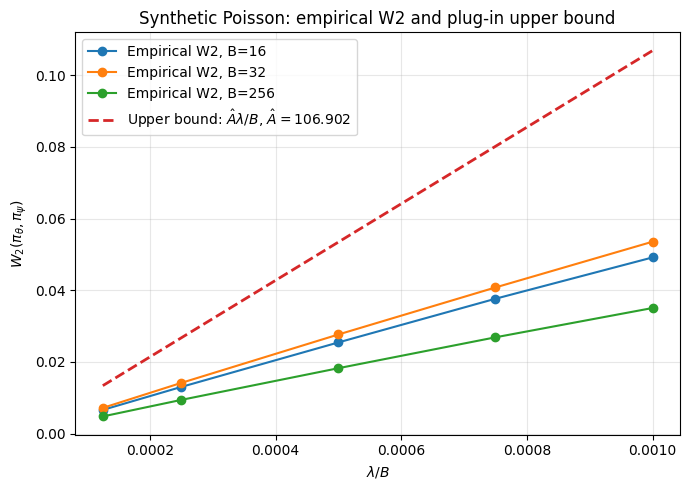

In [ ]:
def compute_poisson_sgd_upper_bound_constant(X, y, theta_hat, clip=30.0):
    """
    Plug-in proxy for the SGD bound:
        W2(pi_theta, pi_psi) <= A * (lambda / B)
    using the Poisson model structure in the current code.
    """
    N, d = X.shape

    eta = np.clip(X @ theta_hat, -clip, clip)
    mu_vec = np.exp(eta)

    # empirical Hessian at theta_hat
    H_hat = (X.T * mu_vec) @ X / N
    H_hat = 0.5 * (H_hat + H_hat.T)

    eigvals = np.linalg.eigvalsh(H_hat)
    mu = float(np.min(eigvals))
    L = float(np.max(eigvals))
    hat_mu = mu

    # third-derivative proxy for Poisson
    x_norm = np.linalg.norm(X, axis=1)
    M_i = mu_vec * (x_norm ** 3)
    M_bar = float(np.mean(M_i))
    M2_bar = float(np.mean(M_i ** 2))

    # fourth moment of sample gradient noise at theta_hat
    g = ((mu_vec - y)[:, None]) * X
    g_bar = np.mean(g, axis=0)
    tau4_4 = float(np.mean(np.linalg.norm(g - g_bar, axis=1) ** 4))

    C0 = (2.0 / mu) * (M2_bar / (8.0 * L) + (M_bar ** 2) / (4.0 * mu))
    A0 = 96.0 * C0 * tau4_4 / (hat_mu ** 2)
    A = float(np.sqrt(A0))

    return {
        "A": A,
        "A0": A0,
        "C0": C0,
        "mu": mu,
        "L": L,
        "hat_mu": hat_mu,
        "M_bar": M_bar,
        "M2_bar": M2_bar,
        "tau4_4": tau4_4,
    }


def add_sgd_upper_bound_column(results_df, A):
    out = results_df.copy()
    out["upper_bound"] = A * out["lambda_over_B"]
    return out


def plot_w2_with_upper_bound(results_df, A, title=None):
    plt.figure(figsize=(7, 5))

    # left-hand side curves from experiments
    for B in sorted(results_df["B"].unique()):
        sub = results_df[results_df["B"] == B].sort_values("lambda_over_B")
        plt.plot(
            sub["lambda_over_B"].to_numpy(),
            sub["w2_mean"].to_numpy(),
            marker="o",
            label=f"Empirical W2, B={B}"
        )

    # right-hand side bound
    x_all = np.sort(results_df["lambda_over_B"].unique())
    plt.plot(
        x_all,
        A * x_all,
        linestyle="--",
        linewidth=2,
        label=fr"Upper bound: $\hat A \lambda/B$, $\hat A={A:.3f}$"
    )

    plt.xlabel(r"$\lambda/B$")
    plt.ylabel(r"$W_2(\pi_\theta,\pi_\psi)$")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

bound_info_syn_pois = compute_poisson_sgd_upper_bound_constant(
    X_syn_pois, y_syn_pois, theta_hat_syn_pois
)
print("\nSynthetic Poisson plug-in bound info:")
for k, v in bound_info_syn_pois.items():
    print(f"{k}: {v}")

results_syn_pois_with_bd = add_sgd_upper_bound_column(
    results_syn_pois, bound_info_syn_pois["A"]
)
print(results_syn_pois_with_bd[["B", "lambda_over_B", "w2_mean", "upper_bound"]])

plot_w2_with_upper_bound(
    results_syn_pois,
    A=bound_info_syn_pois["A"],
    title="Synthetic Poisson: empirical W2 and plug-in upper bound"
)